Check whether the input file ch4.fdf contains the correct basis settings for the SZ_250 case?

In [5]:
%cd ~/siesta-docs/work-files/tutorials/basic/first-encounter/02-CH4-Basis

/home/gaffu/siesta-docs/work-files/tutorials/basic/first-encounter/02-CH4-Basis


In [6]:
!mkdir -p exercise_2


In [7]:
!cp ch4.fdf C.psml H.psml exercise_2/


In [8]:
%cd exercise_2


/home/gaffu/siesta-docs/work-files/tutorials/basic/first-encounter/02-CH4-Basis/exercise_2


In [9]:
!mkdir SZ_250

mkdir: cannot create directory ‘SZ_250’: File exists


In [10]:
!cp ch4.fdf C.psml H.psml SZ_250/


In [11]:
%cd SZ_250


/home/gaffu/siesta-docs/work-files/tutorials/basic/first-encounter/02-CH4-Basis/exercise_2/SZ_250


In [12]:
!sed -n '1,200p' ch4.fdf


#General system specifications
SystemName          CH4 molecule
SystemLabel         ch4
NumberOfAtoms       5
NumberOfSpecies     2

# Species index, atomic number, species label
%block ChemicalSpeciesLabel
 1  6 C
 2  1 H
%endblock ChemicalSpeciesLabel

#Atomic coordinates
AtomicCoordinatesFormat  Ang
%block AtomicCoordinatesAndAtomicSpecies
  0.000      0.000      0.000   1
  1.219     -0.284     -0.377   2
 -0.284      1.219     -0.377   2
 -0.140     -0.140      1.219   2
 -0.833     -0.833     -0.503   2
%endblock AtomicCoordinatesAndAtomicSpecies

#Unit cell for the calculation
LatticeConstant 15 Ang
%block LatticeVectors
  1.000 0.000 0.000
  0.000 1.000 0.000
  0.000 0.000 1.000
%endblock LatticeVectors

#Real space grid
MeshCutoff 125.0 Ry

# Convergence of SCF
DM.MixingWeight 0.4
DM.NumberPulay  2

# Variables for Geometry optimization
# MD.TypeOfRun   CG
# MD.NumCGsteps  50

# Basis set definition
PAO.BasisSize   SZ
PAO.EnergyShift 250 meV


In [13]:
!siesta ch4.fdf > ch4.out


Job completed


In [14]:
!grep "SCF cycle converged" ch4.out


SCF cycle converged after 1 iterations


In [15]:
!grep "Total =" ch4.out


siesta:         Total =    -222.538221


In [16]:
%cd ..

/home/gaffu/siesta-docs/work-files/tutorials/basic/first-encounter/02-CH4-Basis/exercise_2


In [17]:
!mkdir SZ_50


mkdir: cannot create directory ‘SZ_50’: File exists


In [18]:
!cp ch4.fdf C.psml H.psml SZ_50/


In [19]:
%cd SZ_50

/home/gaffu/siesta-docs/work-files/tutorials/basic/first-encounter/02-CH4-Basis/exercise_2/SZ_50


In [20]:
!sed -n '1,200p' ch4.fdf

#General system specifications
SystemName          CH4 molecule
SystemLabel         ch4
NumberOfAtoms       5
NumberOfSpecies     2

# Species index, atomic number, species label
%block ChemicalSpeciesLabel
 1  6 C
 2  1 H
%endblock ChemicalSpeciesLabel

#Atomic coordinates
AtomicCoordinatesFormat  Ang
%block AtomicCoordinatesAndAtomicSpecies
  0.000      0.000      0.000   1
  1.219     -0.284     -0.377   2
 -0.284      1.219     -0.377   2
 -0.140     -0.140      1.219   2
 -0.833     -0.833     -0.503   2
%endblock AtomicCoordinatesAndAtomicSpecies

#Unit cell for the calculation
LatticeConstant 15 Ang
%block LatticeVectors
  1.000 0.000 0.000
  0.000 1.000 0.000
  0.000 0.000 1.000
%endblock LatticeVectors

#Real space grid
MeshCutoff 125.0 Ry

# Convergence of SCF
DM.MixingWeight 0.4
DM.NumberPulay  2

# Variables for Geometry optimization
# MD.TypeOfRun   CG
# MD.NumCGsteps  50

# Basis set definition
PAO.BasisSize   SZ
PAO.EnergyShift 250 meV


In [21]:
!sed -i 's/PAO.EnergyShift 250 meV/PAO.EnergyShift 50 meV/' ch4.fdf


In [22]:
!grep "PAO.EnergyShift" ch4.fdf


PAO.EnergyShift 50 meV


In [23]:
!siesta ch4.fdf > ch4.out


Job completed


In [24]:
!grep "SCF cycle converged" ch4.out


SCF cycle converged after 1 iterations


In [25]:
!grep "Total =" ch4.out


siesta:         Total =    -222.120731


In [26]:
%cd ..

/home/gaffu/siesta-docs/work-files/tutorials/basic/first-encounter/02-CH4-Basis/exercise_2


In [27]:
energy_shifts = [10, 50, 100, 150, 200, 250, 300]

for es in energy_shifts:
    folder = f"SZ_{es}"
    
    # create folder
    !mkdir -p {folder}
    
    # copy inputs
    !cp ch4.fdf C.psml H.psml {folder}/
    
    # modify EnergyShift
    !sed -i "s/PAO.EnergyShift.*/PAO.EnergyShift {es} meV/" {folder}/ch4.fdf
    
    # run SIESTA
    !cd {folder} && siesta ch4.fdf > ch4.out


Job completed
Job completed
Job completed
Job completed
Job completed
Job completed
Job completed


In [28]:
for es in energy_shifts:
    print(es, end="  ")
    !grep "Total =" SZ_{es}/ch4.out


10  siesta:         Total =    -221.815381
50  siesta:         Total =    -222.120731
100  siesta:         Total =    -222.329599
150  siesta:         Total =    -222.451472
200  siesta:         Total =    -222.515031
250  siesta:         Total =    -222.538221
300  siesta:         Total =    -222.530567


In [29]:
basis_sets = ["SZ", "DZ", "SZP", "DZP", "TZP"]
energy_shifts = [10, 50, 100, 150, 200, 250, 300]

for basis in basis_sets:
    for es in energy_shifts:
        folder = f"{basis}_{es}"
        print(f"Running {folder}")

        # create folder
        !mkdir -p {folder}

        # copy inputs
        !cp ch4.fdf C.psml H.psml {folder}/

        # set basis
        !sed -i "s/PAO.BasisSize.*/PAO.BasisSize {basis}/" {folder}/ch4.fdf

        # set energy shift
        !sed -i "s/PAO.EnergyShift.*/PAO.EnergyShift {es} meV/" {folder}/ch4.fdf

        # run siesta
        !cd {folder} && siesta ch4.fdf > ch4.out


Running SZ_10
Job completed
Running SZ_50
Job completed
Running SZ_100
Job completed
Running SZ_150
Job completed
Running SZ_200
Job completed
Running SZ_250
Job completed
Running SZ_300
Job completed
Running DZ_10
Job completed
Running DZ_50
Job completed
Running DZ_100
Job completed
Running DZ_150
Job completed
Running DZ_200
Job completed
Running DZ_250
Job completed
Running DZ_300
Job completed
Running SZP_10
Job completed
Running SZP_50
Job completed
Running SZP_100
Job completed
Running SZP_150
Job completed
Running SZP_200
Job completed
Running SZP_250
Job completed
Running SZP_300
Job completed
Running DZP_10
Job completed
Running DZP_50
Job completed
Running DZP_100
Job completed
Running DZP_150
Job completed
Running DZP_200
Job completed
Running DZP_250
Job completed
Running DZP_300
Job completed
Running TZP_10
Job completed
Running TZP_50
Job completed
Running TZP_100
Job completed
Running TZP_150
Job completed
Running TZP_200
Job completed
Running TZP_250
Job completed
Runn

In [30]:
for basis in basis_sets:
    print(f"\n{basis}")
    for es in energy_shifts:
        print(f"{es:>4} meV :", end=" ")
        !grep "Total =" {basis}_{es}/ch4.out



SZ
  10 meV : siesta:         Total =    -221.815381
  50 meV : siesta:         Total =    -222.120731
 100 meV : siesta:         Total =    -222.329599
 150 meV : siesta:         Total =    -222.451472
 200 meV : siesta:         Total =    -222.515031
 250 meV : siesta:         Total =    -222.538221
 300 meV : siesta:         Total =    -222.530567

DZ
  10 meV : siesta:         Total =    -224.298441
  50 meV : siesta:         Total =    -224.303287
 100 meV : siesta:         Total =    -224.242980
 150 meV : siesta:         Total =    -224.150452
 200 meV : siesta:         Total =    -224.040218
 250 meV : siesta:         Total =    -223.913569
 300 meV : siesta:         Total =    -223.777144

SZP
  10 meV : siesta:         Total =    -222.899532
  50 meV : siesta:         Total =    -222.912168
 100 meV : siesta:         Total =    -222.906215
 150 meV : siesta:         Total =    -222.888845
 200 meV : siesta:         Total =    -222.861886
 250 meV : siesta:         Total =   

In [31]:

energies = {}

for basis in basis_sets:
    energies[basis] = []        # empty list for this basis
    print(f"\n{basis}")
    
    for es in energy_shifts:
        with open(f"{basis}_{es}/ch4.out") as f:
            for line in f:
                if "Total =" in line:
                    E = float(line.split()[-1])
                    energies[basis].append(E)
                    print(f"{es:>4} meV : {E}")



SZ
  10 meV : -221.815381
  50 meV : -222.120731
 100 meV : -222.329599
 150 meV : -222.451472
 200 meV : -222.515031
 250 meV : -222.538221
 300 meV : -222.530567

DZ
  10 meV : -224.298441
  50 meV : -224.303287
 100 meV : -224.24298
 150 meV : -224.150452
 200 meV : -224.040218
 250 meV : -223.913569
 300 meV : -223.777144

SZP
  10 meV : -222.899532
  50 meV : -222.912168
 100 meV : -222.906215
 150 meV : -222.888845
 200 meV : -222.861886
 250 meV : -222.825577
 300 meV : -222.781972

DZP
  10 meV : -224.59925
  50 meV : -224.655131
 100 meV : -224.633295
 150 meV : -224.568371
 200 meV : -224.482504
 250 meV : -224.380785
 300 meV : -224.271633

TZP
  10 meV : -224.619569
  50 meV : -224.6773
 100 meV : -224.65185
 150 meV : -224.585309
 200 meV : -224.498285
 250 meV : -224.39559
 300 meV : -224.285387


In [32]:
energies


{'SZ': [-221.815381,
  -222.120731,
  -222.329599,
  -222.451472,
  -222.515031,
  -222.538221,
  -222.530567],
 'DZ': [-224.298441,
  -224.303287,
  -224.24298,
  -224.150452,
  -224.040218,
  -223.913569,
  -223.777144],
 'SZP': [-222.899532,
  -222.912168,
  -222.906215,
  -222.888845,
  -222.861886,
  -222.825577,
  -222.781972],
 'DZP': [-224.59925,
  -224.655131,
  -224.633295,
  -224.568371,
  -224.482504,
  -224.380785,
  -224.271633],
 'TZP': [-224.619569,
  -224.6773,
  -224.65185,
  -224.585309,
  -224.498285,
  -224.39559,
  -224.285387]}

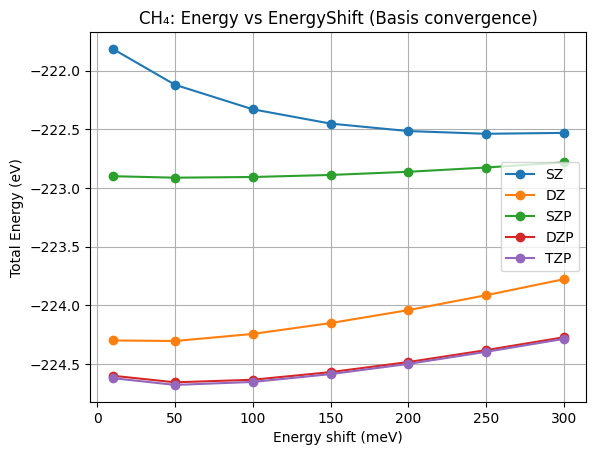

In [33]:
import matplotlib.pyplot as plt

for basis in energies:
    plt.plot(energy_shifts, energies[basis], marker='o', label=basis)

plt.xlabel("Energy shift (meV)")
plt.ylabel("Total Energy (eV)")
plt.title("CH₄: Energy vs EnergyShift (Basis convergence)")
plt.legend()
plt.grid(True)
plt.show()
